In [2]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 14.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

from Bio import AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment

import numpy as np
import pandas as pd

from Bio.PDB import PDBParser, PDBIO

from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Input and output file paths
input_file = '/content/drive/MyDrive/Staller Lab Research/Gal11Mapping/med15_KIX_filtered (1).align'
output_file = 'converted_alignment.fasta'

# Read the alignment from the input file
try:
    with open(input_file, 'r') as file:
        lines = file.readlines()

    sequences = []
    current_seq_id = ""
    current_seq = []

    for line in lines:
        if line.startswith('>'):
            if current_seq_id:
                sequences.append(SeqRecord(Seq(''.join(current_seq)), id=current_seq_id, description=""))
            current_seq_id = line.strip().lstrip('>')
            current_seq = []
        else:
            current_seq.append(line.strip())

    if current_seq_id:
        sequences.append(SeqRecord(Seq(''.join(current_seq)), id=current_seq_id, description=""))

    alignment = MultipleSeqAlignment(sequences)

    AlignIO.write(alignment, output_file, 'fasta')

    print(f"File converted and saved to {output_file}.")

except Exception as e:
    print(f"An error occurred: {e}")



File converted and saved to converted_alignment.fasta.


In [5]:
# Method to store fasta sequences in a string
def read_amino_acid_sequence(file_path):
    with open(file_path, 'r') as file:
        next(file)
        sequence = ''.join(line.strip() for line in file)
    return sequence

In [6]:
# consensus sequence
consensus_file_path = '/content/drive/MyDrive/Staller Lab Research/Gal11Mapping/ClaireAlignmentConsensus.txt'
consensus_sequence = read_amino_acid_sequence(consensus_file_path)

# g002133
g002133_file_path = '/content/drive/MyDrive/Staller Lab Research/Gal11Mapping/g002133.m1__saccharomyces_cerevisiae_1-1081.txt'
g002133_sequence = read_amino_acid_sequence(g002133_file_path)

In [7]:
g002133_sequence_array = list(g002133_sequence)
consensus_sequence_array = list(consensus_sequence)

In [8]:
def read_fasta_file(filename):
    """
    Reads a FASTA file and returns a list of protein sequences.
    :param filename: name of the FASTA file to read
    :return: a list of protein sequences as strings
    """
    sequences = []
    with open(filename) as f:
        sequence = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if sequence:
                    sequences.append(sequence)
                    sequence = ""
            else:
                sequence += line
        if sequence:
            sequences.append(sequence)
    return sequences

In [9]:
# Claire's Alignments here
sequences = read_fasta_file('/content/drive/MyDrive/Staller Lab Research/Gal11Mapping/converted_alignment.fasta')
len(sequences)

653

In [10]:
def calculate_percentage_identity(sequences):
    num_sequences = len(sequences)
    sequence_length = len(sequences[0])
    identity_array = np.zeros(sequence_length)

    for i in range(sequence_length):
        residues_at_position = [sequence[i] for sequence in sequences if sequence[i] != '-']
        if len(residues_at_position) == 0:
            identity_array[i] = 0
        else:
            most_common_residue = max(set(residues_at_position), key=residues_at_position.count)
            num_common_residues = residues_at_position.count(most_common_residue)
            percentage_identity = (num_common_residues / num_sequences) * 100
            identity_array[i] = percentage_identity

    return identity_array

In [11]:
percent_identities = calculate_percentage_identity(sequences)

In [12]:
def gal11_percent_identity_map(identity_array, msa_gal11_sequence):
    gal11_identity = []
    for i in range(len(msa_gal11_sequence)):
        if msa_gal11_sequence[i] != '-':
            gal11_identity.append(identity_array[i])
    return gal11_identity

gal11_percent_identities = gal11_percent_identity_map(percent_identities, g002133_sequence_array)

#confirms that we have a correct mapping to gal11 sequence of interest
len(gal11_percent_identities) == 1081


True

In [13]:
parser = PDBParser()
structure = parser.get_structure("Gal11", "/content/drive/MyDrive/Staller Lab Research/Gal11Mapping/Gal11.pdb")

for residue, identity in zip(structure[0]["A"].get_residues(), gal11_percent_identities):
    residue["CA"].bfactor = identity

io = PDBIO()
io.set_structure(structure)
io.save("Gal11_projectedPercentIdentities.pdb")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Staller Lab Research/Gal11Mapping/Gal11.pdb'

In [14]:
#Calculating the average percent identity
print("Percent identity in entire gal 11 protein:", np.mean(gal11_percent_identities))

#Calculating the average percent identity in kix domain
print("Percent identity in kix:", np.mean(gal11_percent_identities[5:90]))

#Calculating the average percent identity in abd1
print("Percent identity in abd1:", np.mean(gal11_percent_identities[157:237]))

#Calculating average percent identity in abd2
print("Percent identity in abd2:", np.mean(gal11_percent_identities[276:367]))

#calculating average percent identity in abd3
print("Percent identity in abd3:", np.mean(gal11_percent_identities[484:651]))

Percent identity in entire gal 11 protein: 35.20632730456316
Percent identity in kix: 46.339969372128635
Percent identity in abd1: 57.461715160796324
Percent identity in abd2: 41.48057149588543
Percent identity in abd3: 47.309974232239966


KIX region is more conserved than other regions (corrected p-value = 0.0003999600)


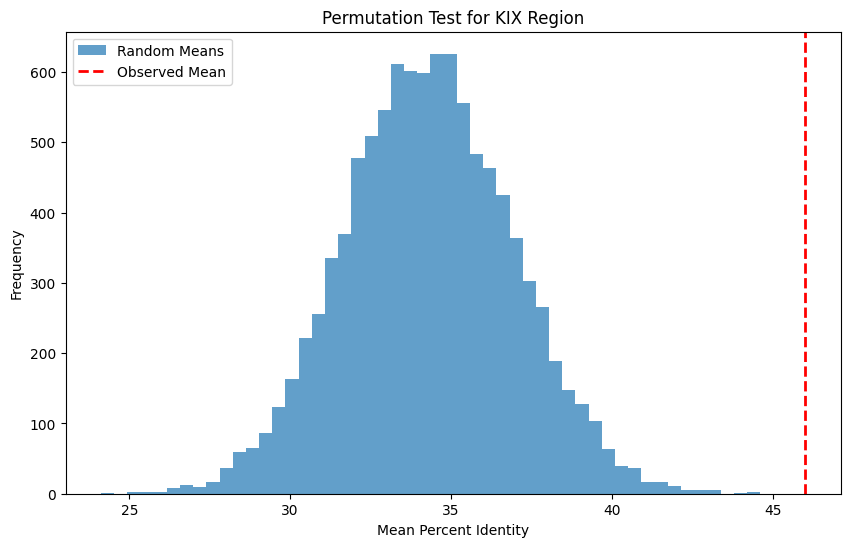

ABD1 region is more conserved than other regions (corrected p-value = 0.0003999600)


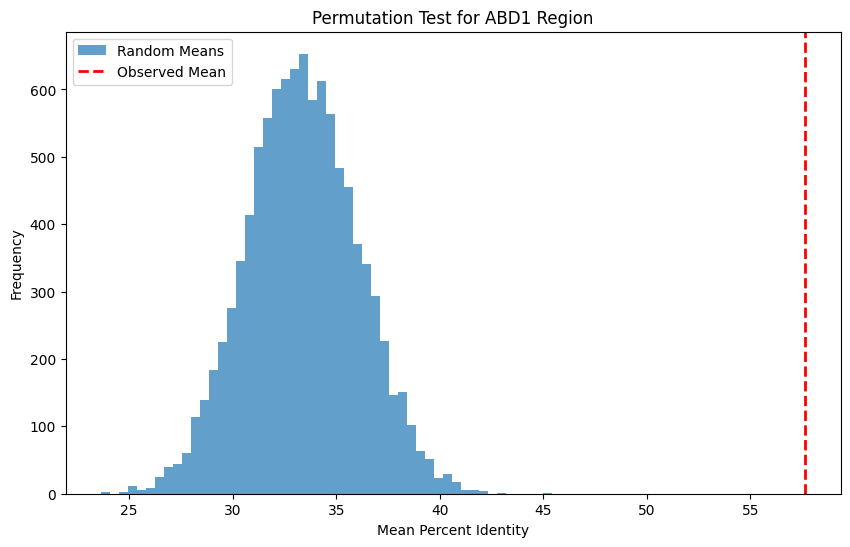

ABD2 region is not more conserved than other regions (corrected p-value = 0.0279972003)


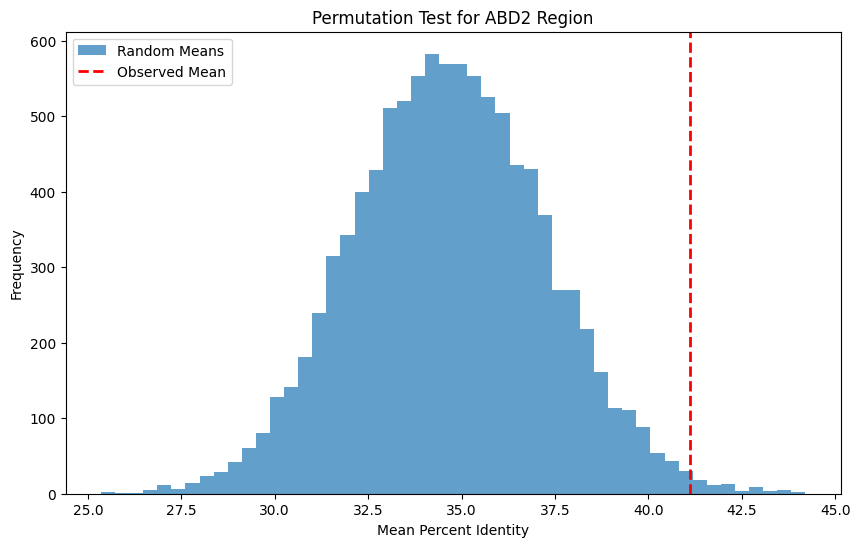

ABD3 region is more conserved than other regions (corrected p-value = 0.0003999600)


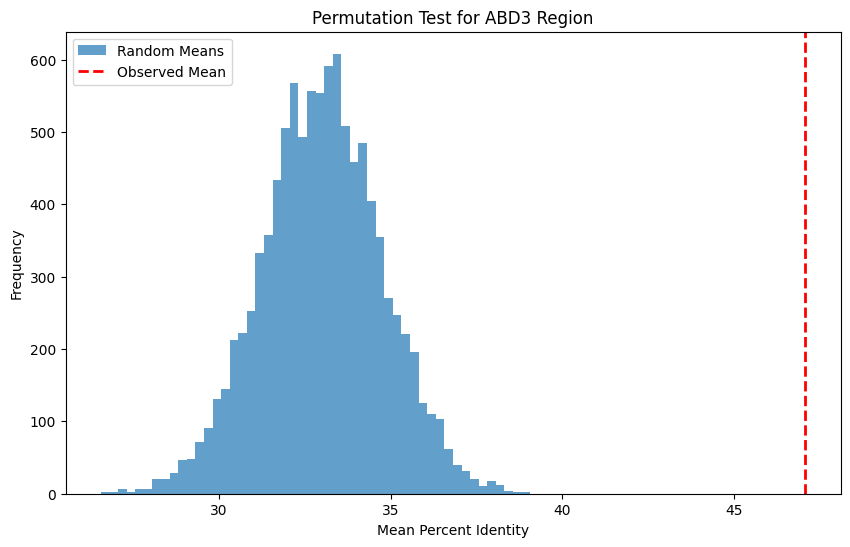

In [19]:
num_samples = 10000

regions = [
    {'name': 'KIX', 'start': 5, 'end': 90},
    {'name': 'ABD1', 'start': 157, 'end': 237},
    {'name': 'ABD2', 'start': 276, 'end': 367},
    {'name': 'ABD3', 'start': 484, 'end': 651}
]

save_folder = '/content/drive/My Drive/Colab Notebooks/MyPlots/'
os.makedirs(save_folder, exist_ok=True)

for region in regions:
    sample_size = region['end'] - region['start'] + 1
    region_percent_identities = gal11_percent_identities[region['start']:region['end'] + 1]
    region_mean = np.mean(region_percent_identities)

    # Excluding region of interest
    rest_percent_identities = np.concatenate([
        gal11_percent_identities[:region['start']],
        gal11_percent_identities[region['end'] + 1:]
    ])

    # Generate random samples from the rest of the protein
    random_means = []
    for _ in range(num_samples):
        sample = np.random.choice(rest_percent_identities, size=sample_size, replace=False)
        random_means.append(np.mean(sample))
    random_means = np.array(random_means)

    p_value = (np.sum(random_means >= region_mean) + 1) / (num_samples + 1)

    # Bonferroni correction
    corrected_p_value = p_value * len(regions)
    corrected_p_value = min(corrected_p_value, 1.0)  # Ensure p-value does not exceed 1

    if corrected_p_value < 0.005:
        print(f"{region['name']} region is more conserved than other regions (corrected p-value = {corrected_p_value:.10f})")
    else:
        print(f"{region['name']} region is not more conserved than other regions (corrected p-value = {corrected_p_value:.10f})")

    plt.figure(figsize=(10, 6))
    plt.hist(random_means, bins=50, alpha=0.7, label='Random Means')
    plt.axvline(region_mean, color='red', linestyle='dashed', linewidth=2, label='Observed Mean')
    plt.title(f"Permutation Test for {region['name']} Region")
    plt.xlabel('Mean Percent Identity')
    plt.ylabel('Frequency')
    plt.legend()

    save_path = os.path.join(save_folder, f"{region['name']}_permutation_histogram.pdf")
    plt.savefig(save_path)
    plt.show()
    plt.close()


In [20]:
for region in regions:
    region_percent_identities = gal11_percent_identities[region['start']:region['end'] + 1]
    rest_percent_identities = np.concatenate([
        gal11_percent_identities[:region['start']],
        gal11_percent_identities[region['end'] + 1:]
    ])

    # Mann-Whitney U Test
    u_statistic, p_value = stats.mannwhitneyu(
        region_percent_identities,
        rest_percent_identities,
        alternative='greater'
    )

    # Bonferroni correction
    corrected_p_value = p_value * len(regions)

    if corrected_p_value < 0.005:
        print(f"{region['name']} region is more conserved than other regions (corrected p-value = {corrected_p_value:.10f})")
    else:
        print(f"{region['name']} region is not more conserved than other regions (corrected p-value = {corrected_p_value:.10f})")


KIX region is more conserved than other regions (corrected p-value = 0.0000433505)
ABD1 region is more conserved than other regions (corrected p-value = 0.0000000000)
ABD2 region is not more conserved than other regions (corrected p-value = 0.0114908468)
ABD3 region is more conserved than other regions (corrected p-value = 0.0000000001)


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


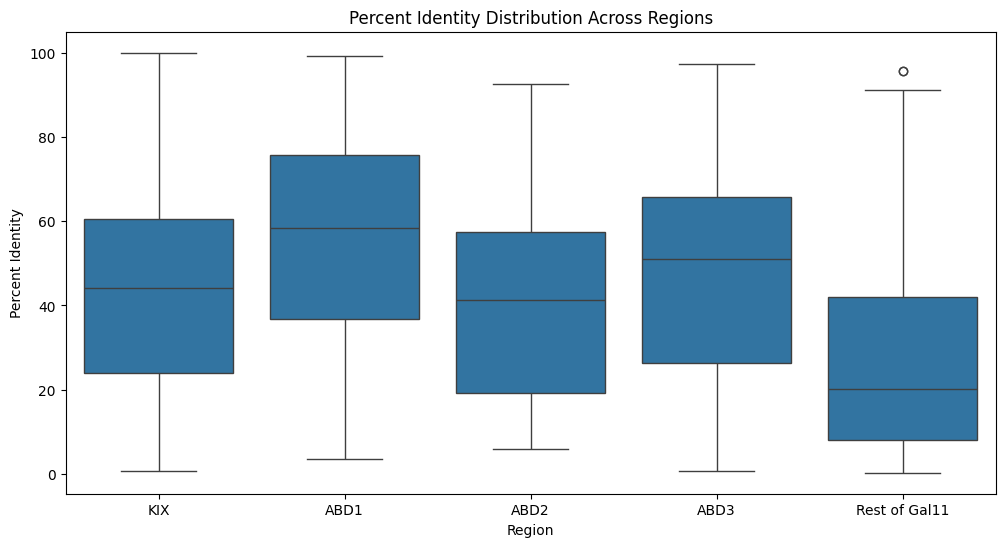

In [21]:
save_folder = '/content/drive/My Drive/Colab Notebooks/MyPlots/'
os.makedirs(save_folder, exist_ok=True)

data = []
for region in regions:
    region_percent_identities = gal11_percent_identities[region['start']:region['end'] + 1]
    for value in region_percent_identities:
        data.append({'Region': region['name'], 'Percent Identity': value})

# everything besides region of interest
rest_regions = []
for region in regions:
    rest_regions.extend(range(region['start'], region['end'] + 1))

rest_percent_identities = np.delete(gal11_percent_identities, rest_regions)
for value in rest_percent_identities:
    data.append({'Region': 'Rest of Gal11', 'Percent Identity': value})

df = pd.DataFrame(data)


plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Percent Identity', data=df)
plt.title('Percent Identity Distribution Across Regions')


save_path = os.path.join(save_folder, 'Percent_Identity_Distribution_Across_Regions.pdf')
plt.savefig(save_path)
plt.show()
plt.close()


In [22]:
#ABD1 Hydrophobic Cleft touching residues
abd1_hydrophobic_residues = [161, 166, 168, 169, 198, 199, 202, 212, 215, 216, 219]
abd1_hydrophobic_cleft = [gal11_percent_identities[position] for position in abd1_hydrophobic_residues]

Hydrophobic cleft residues are not more conserved than the rest of ABD1 (p-value = 0.6059709430)


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


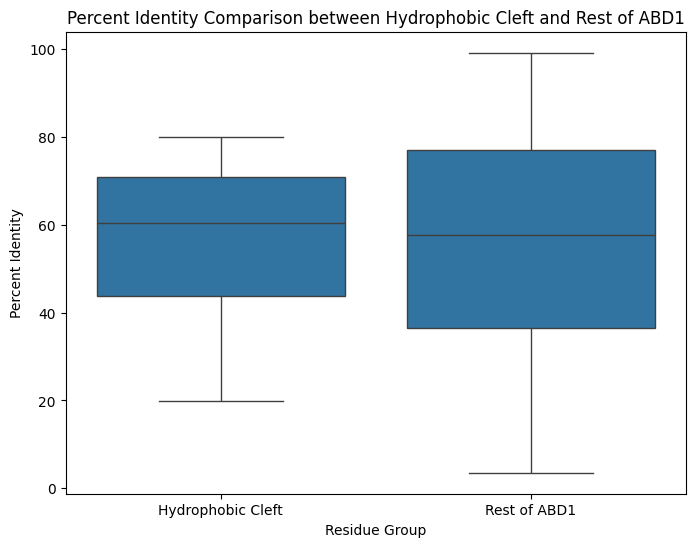

In [23]:
abd1 = {'name': 'ABD1', 'start': 157, 'end': 237}

#ABD1 Hydrophobic Cleft touching residues
abd1_hydrophobic_residues = [161, 166, 168, 169, 198, 199, 202, 212, 215, 216, 219]
abd1_hydrophobic_cleft = [gal11_percent_identities[position] for position in abd1_hydrophobic_residues]

# Percent identities for the rest of ABD1 region
abd1_all_indices = np.arange(abd1['start'], abd1['end'] + 1)
abd1_rest_indices = np.setdiff1d(abd1_all_indices, abd1_hydrophobic_residues)
abd1_rest = [gal11_percent_identities[position] for position in abd1_rest_indices]

# Mann-Whitney U Test
u_statistic, p_value = stats.mannwhitneyu(
    abd1_hydrophobic_cleft,
    abd1_rest,
    alternative='greater'
)

if p_value < 0.05:
    print(f"Hydrophobic cleft residues are more conserved than the rest of ABD1 (p-value = {p_value:.10f})")
else:
    print(f"Hydrophobic cleft residues are not more conserved than the rest of ABD1 (p-value = {p_value:.10f})")

data = []

for value in abd1_hydrophobic_cleft:
    data.append({'Residue Group': 'Hydrophobic Cleft', 'Percent Identity': value})

for value in abd1_rest:
    data.append({'Residue Group': 'Rest of ABD1', 'Percent Identity': value})

df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.boxplot(x='Residue Group', y='Percent Identity', data=df)
plt.title('Percent Identity Comparison between Hydrophobic Cleft and Rest of ABD1')


save_path = os.path.join(save_folder, 'Percent_Identity_Hydrophobic_Cleft_ABD1.pdf')
plt.savefig(save_path)
plt.show()
plt.close()




Hydrophobic cleft residues are not more conserved than the rest of ABD1 (p-value = 0.6325367463)


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


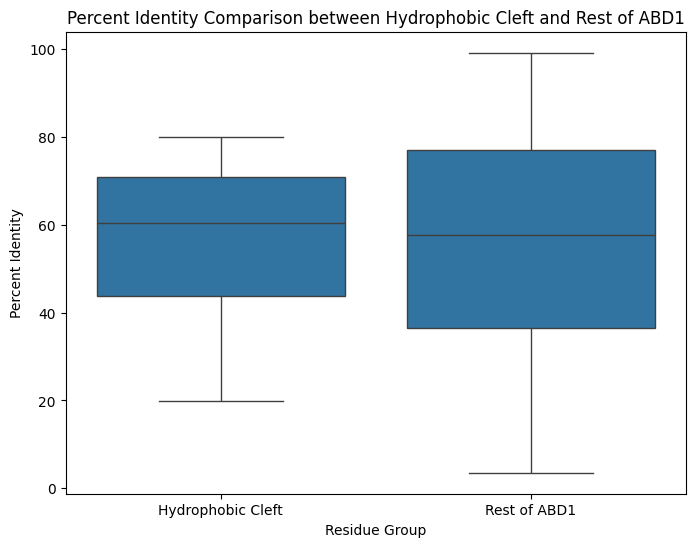

In [24]:
# Permutation test
num_permutations = 10000
observed_mean_difference = np.mean(abd1_hydrophobic_cleft) - np.mean(abd1_rest)
combined_data = np.concatenate([abd1_hydrophobic_cleft, abd1_rest])
n_cleft = len(abd1_hydrophobic_cleft)

count = 0
for _ in range(num_permutations):
    np.random.shuffle(combined_data)
    permuted_cleft = combined_data[:n_cleft]
    permuted_rest = combined_data[n_cleft:]
    permuted_mean_difference = np.mean(permuted_cleft) - np.mean(permuted_rest)
    if permuted_mean_difference >= observed_mean_difference:
        count += 1

p_value = (count + 1) / (num_permutations + 1)  # Adding 1 to numerator and denominator to avoid p-value of zero

if p_value < 0.05:
    print(f"Hydrophobic cleft residues are more conserved than the rest of ABD1 (p-value = {p_value:.10f})")
else:
    print(f"Hydrophobic cleft residues are not more conserved than the rest of ABD1 (p-value = {p_value:.10f})")


data = []

for value in abd1_hydrophobic_cleft:
    data.append({'Residue Group': 'Hydrophobic Cleft', 'Percent Identity': value})

for value in abd1_rest:
    data.append({'Residue Group': 'Rest of ABD1', 'Percent Identity': value})

df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.boxplot(x='Residue Group', y='Percent Identity', data=df)
plt.title('Percent Identity Comparison between Hydrophobic Cleft and Rest of ABD1')
plt.xlabel('Residue Group')
plt.ylabel('Percent Identity')

save_path = os.path.join(save_folder, 'Permutation_Percent_Identity_Hydrophobic_Cleft_ABD1.pdf')
plt.savefig(save_path)
plt.show()
plt.close()


In [25]:
def plot_percent_identity(
    amino_acid_positions,
    percent_identity,
    title,
    regions_of_interest=None,
    filename=None,
    save_folder=None
):
    plt.figure(figsize=(12, 6))

    plt.plot(
        amino_acid_positions,
        percent_identity,
        color='navy',
        linewidth=1.5,
        label='Percent Identity'
    )

    plt.fill_between(
        amino_acid_positions,
        percent_identity,
        color='lightblue',
        alpha=0.5
    )

    if regions_of_interest:
        for region, label in regions_of_interest.items():
            start, end = region
            plt.axvspan(
                start,
                end,
                color='orange',
                alpha=0.3
            )
            plt.text(
                (start + end) / 2,
                max(percent_identity) * 1,
                label,
                horizontalalignment='center',
                verticalalignment='bottom',
                fontsize=12,
                color='darkred',
                fontweight='bold'
            )

    plt.title(
        title,
        fontsize=16,
        fontweight='bold'
    )
    plt.xlabel(
        'Amino Acid Position',
        fontsize=14
    )
    plt.ylabel(
        'Percent Identity (%)',
        fontsize=14
    )
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 105)
    plt.xlim(min(amino_acid_positions), max(amino_acid_positions))


    plt.grid(
        True,
        linestyle='--',
        linewidth=0.5,
        alpha=0.7
    )

    plt.tight_layout()


    if filename:

        if save_folder is None:
            save_folder = os.getcwd()
        os.makedirs(save_folder, exist_ok=True)
        save_path = os.path.join(save_folder, filename)
        plt.savefig(
            save_path,
            dpi=600,
            bbox_inches='tight',
            format='pdf'
        )
        plt.show()
        plt.close()
        print(f"Figure saved to {save_path}")
    else:
        plt.show()


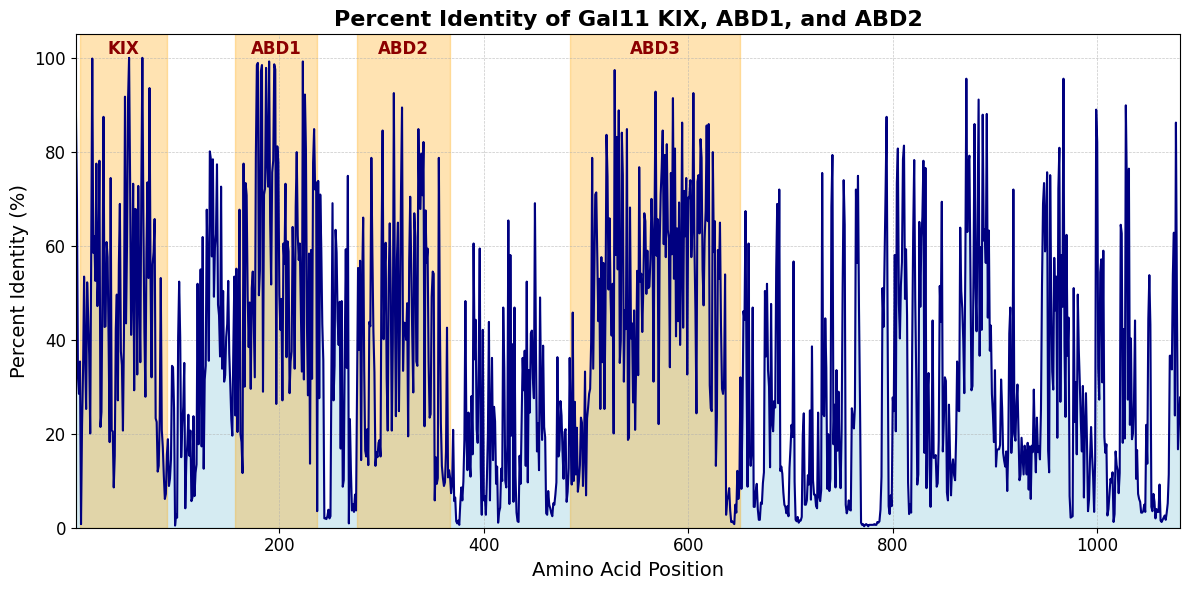

Figure saved to /content/drive/My Drive/Colab Notebooks/MyPlots/Percent_Identity_Gal11.pdf


In [27]:
amino_acid_positions = np.arange(1, 1082)
regions_of_interest = {
    (5, 90): 'KIX',
    (157, 237): 'ABD1',
    (276, 367): 'ABD2',
    (484, 651): 'ABD3'
}
title = 'Percent Identity of Gal11 KIX, ABD1, and ABD2'
plot_percent_identity(
    amino_acid_positions,
    gal11_percent_identities,
    title,
    regions_of_interest=regions_of_interest,
    filename='Percent_Identity_Gal11.pdf',
    save_folder=save_folder
)


In [28]:
def plot_percent_identity_with_touching_residues(
    amino_acid_positions,
    percent_identity,
    regions_of_interest=None,
    touching_residues=None,
    filename=None,
    save_folder=None
):
    plt.figure(figsize=(12, 6))
    plt.plot(
        amino_acid_positions,
        percent_identity,
        color='navy',
        linewidth=1.5
    )
    plt.fill_between(
        amino_acid_positions,
        percent_identity,
        color='lightblue',
        alpha=0.3
    )

    if regions_of_interest:
        for region, label in regions_of_interest.items():
            start, end = region

    if touching_residues:
        first_residue_plotted = False
        for residue in touching_residues:
            index = residue - amino_acid_positions[0]  # Adjusting for the start position
            if 0 <= index < len(amino_acid_positions):
                plt.plot(
                    amino_acid_positions[index],
                    percent_identity[index],
                    marker='*',
                    markersize=12,
                    color='red',
                    label='Hydrophobic Cleft Residues' if not first_residue_plotted else ""
                )
                first_residue_plotted = True

    plt.title('Percent Identity of Gal11 ABD1', fontsize=16, fontweight='bold')
    plt.xlabel('Amino Acid Position', fontsize=14)
    plt.ylabel('Percent Identity (%)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 105)
    plt.xlim(min(amino_acid_positions), max(amino_acid_positions))

    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    handles, labels = plt.gca().get_legend_handles_labels()
    if 'Hydrophobic Cleft Residues' in labels:
        plt.legend(
            fontsize=12,
            loc='upper right',
            frameon=True
        )

    plt.tight_layout()

    if filename:
        if save_folder is None:
            save_folder = os.getcwd()
        os.makedirs(save_folder, exist_ok=True)
        save_path = os.path.join(save_folder, filename)
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='pdf')
        plt.show()
        plt.close()
        print(f"Figure saved to {save_path}")
    else:
        plt.show()


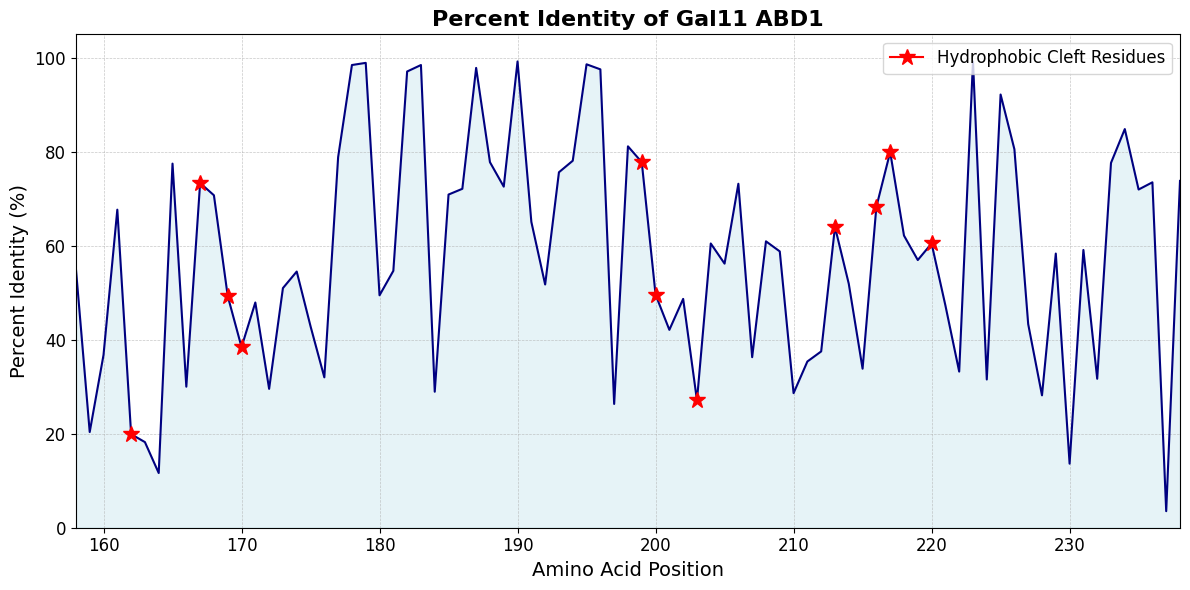

Figure saved to /content/drive/My Drive/Colab Notebooks/MyPlots/Gal11_ABD1_Percent_Identity.pdf


In [29]:
import numpy as np
import os

abd1_start = 158
abd1_end = 238
abd1_positions = np.arange(abd1_start, abd1_end + 1)

abd1_percent_identities = gal11_percent_identities[abd1_start - 1:abd1_end]

# hydrophobic cleft residues that interact with GCN4
touching_residues = [162, 167, 169, 170, 199, 200, 203, 213, 216, 217, 220]

regions_of_interest = {(abd1_start, abd1_end): 'ABD1'}

plot_percent_identity_with_touching_residues(
    amino_acid_positions=abd1_positions,
    percent_identity=abd1_percent_identities,
    regions_of_interest=regions_of_interest,
    touching_residues=touching_residues,
    filename='Gal11_ABD1_Percent_Identity.pdf',
    save_folder=save_folder
)
